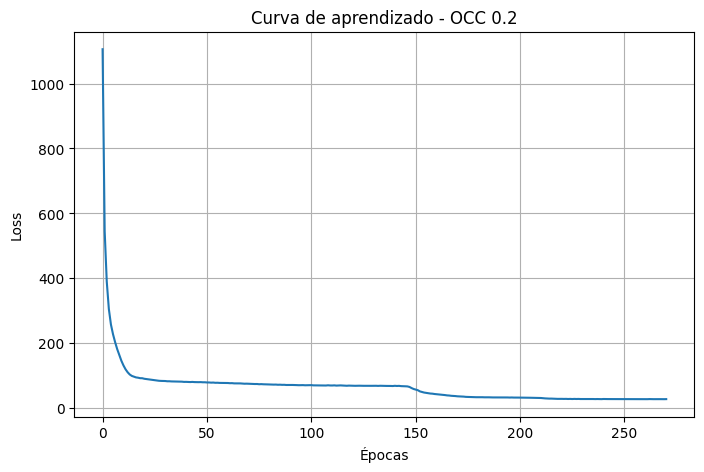

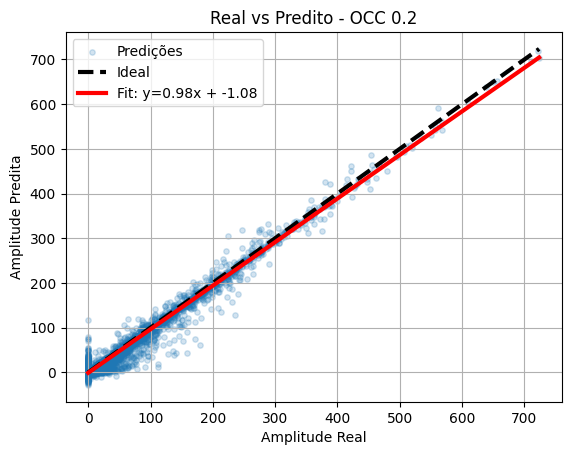


===== OCC 0.2 =====
KFold MAE: 3.509380725002631
Test MAE: 3.689250394047058


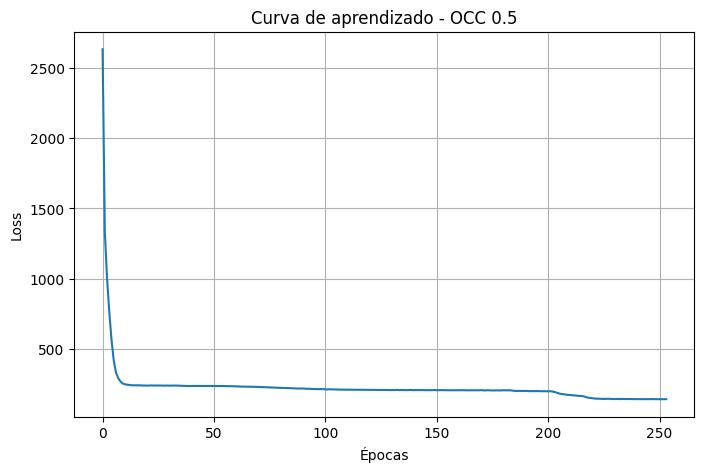

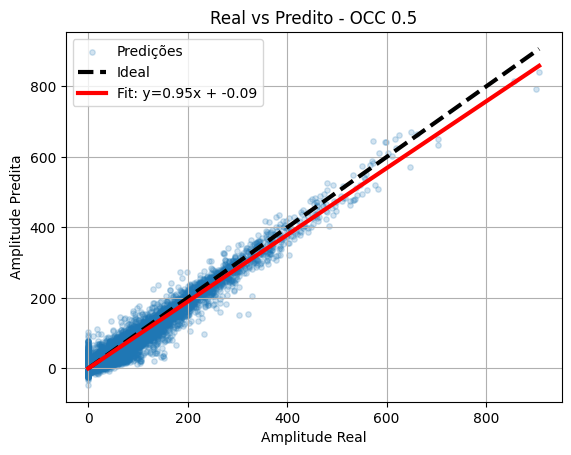


===== OCC 0.5 =====
KFold MAE: 14.047477203005727
Test MAE: 10.849220766877608


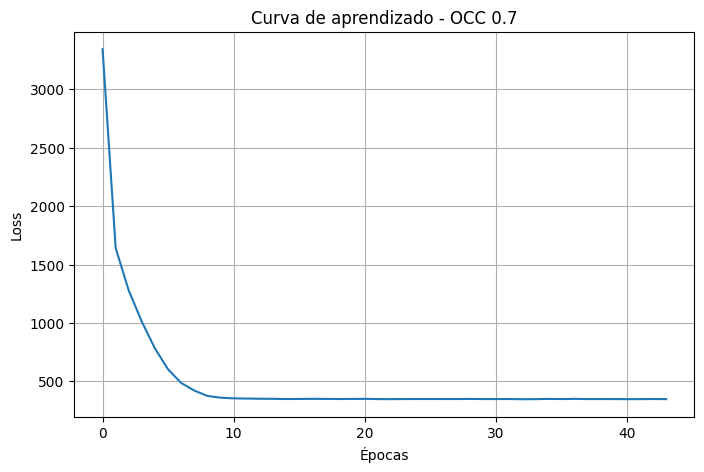

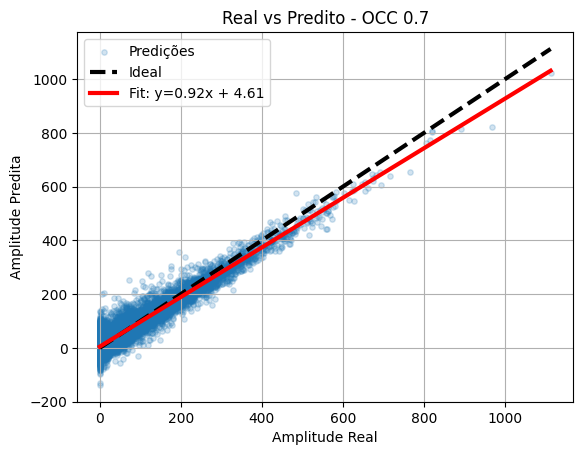


===== OCC 0.7 =====
KFold MAE: 18.710377314729435
Test MAE: 18.845314354347227


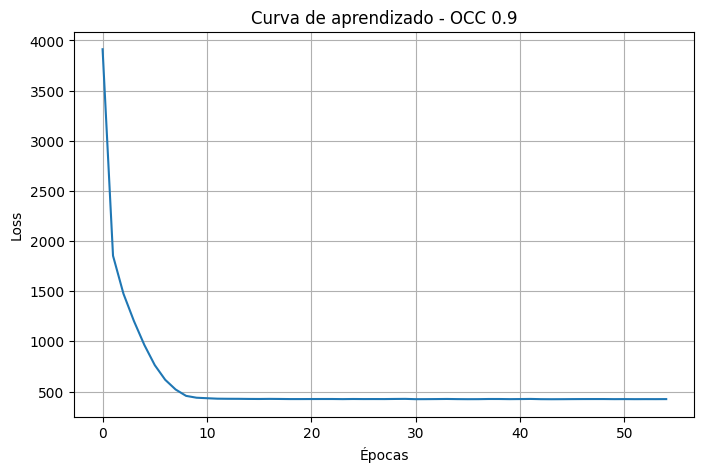

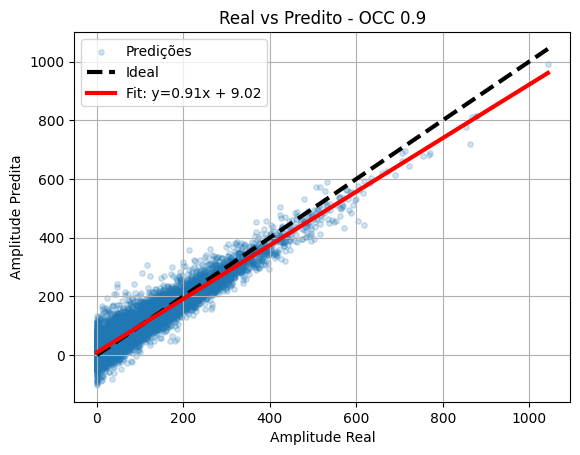


===== OCC 0.9 =====
KFold MAE: 21.450807154267057
Test MAE: 21.51540538513283


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold
from sklearn.base import clone

# importa dados
data = {
    '0.2': '/home/nathalya/Nelder-Mead_Rede-Neural/database/data_occ0_2.csv',
    '0.5': '/home/nathalya/Nelder-Mead_Rede-Neural/database/data_occ0_5.csv',
    '0.7': '/home/nathalya/Nelder-Mead_Rede-Neural/database/data_occ0_7.csv',
    '0.9': '/home/nathalya/Nelder-Mead_Rede-Neural/database/data_occ0_9.csv'
}

# Rede neural

  
base_model = MLPRegressor(
    hidden_layer_sizes=(7,),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

#armazenamento 

results = []
residuals_dict = {}

# Loop da ocupação

for occ, path in data.items():

    df = pd.read_csv(path)

    # Entradas (7 sinais)

    X = df[['sample(0)', 'sample(1)', 'sample(2)',
            'sample(3)', 'sample(4)', 'sample(5)',
            'sample(6)']].values
    
    # Saída (Amplitude)

    y = df['AmplitudeSample(4)'].values

    # Holdout teste (20%)

    X_temp, X_test, y_temp, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

    # K-fold no treino (80%)

    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    fold_mae = []
    fold_std = []

    for train_idx, val_idx in kf.split(X_temp):

        X_train, X_val = X_temp[train_idx], X_temp[val_idx]
        y_train, y_val = y_temp[train_idx], y_temp[val_idx]

        model = clone(base_model)
        model.fit(X_train, y_train)

        y_val_pred = model.predict(X_val)

        residuals = y_val - y_val_pred

        fold_mae.append(np.mean(np.abs(residuals)))
        fold_std.append(np.std(residuals))
    
    #Treino final
    final_model= clone(base_model)
    final_model.fit(X_temp, y_temp)

    # Teste final

    y_test_pred = final_model.predict(X_test)

    test_residuals = y_test - y_test_pred

    test_mae = np.mean(np.abs(test_residuals))
    test_std = np.std(test_residuals)

    #Salvar residuos 
    residuals_dict[occ] = test_residuals
    
    #Erros 

    val_error = np.std(y_val - y_val_pred)

    test_error = np.std(y_test - y_test_pred)


    # Métricas

    results.append({
        'Occupancy': float(occ),

        # K-Fold (validação)
        'KFold_MAE_mean': np.mean(fold_mae),
        'KFold_MAE_std': np.std(fold_mae),
        'KFold_STD_mean': np.mean(fold_std),

        # Teste final
        'Test_MAE': test_mae,
        'Test_STD': test_std
    })

    #Gráficos 

#Curva de aprendizado 
    plt.figure(figsize=(8,5))
    plt.plot(final_model.loss_curve_)
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.title(f'Curva de aprendizado - OCC {occ}')
    plt.grid(True)
    plt.show()

# Real X predição

# fitting linear
    a, b = np.polyfit(y_test, y_test_pred, 1)

# reta ajustada
    x_fit = np.linspace(y_test.min(), y_test.max(), 100)

    y_fit = a * x_fit + b

    plt.scatter(
        y_test,
        y_test_pred,
        alpha=0.2,
        s=15,
        label='Predições'
    )

# ideal        
    plt.plot(
        x_fit,
        x_fit,
        '--',
        color='black',
        linewidth=3,
        label='Ideal'
    )

# fit
    plt.plot(
        x_fit,
        y_fit,
        '-',
        color='red',
        linewidth=3,
        label=f'Fit: y={a:.2f}x + {b:.2f}'
    )

    plt.xlabel('Amplitude Real')
    plt.ylabel('Amplitude Predita')
    plt.title(f'Real vs Predito - OCC {occ}')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\n===== OCC {occ} =====")
    print("KFold MAE:", np.mean(fold_mae))
    print("Test MAE:", test_mae)

# Salva stats 

stats_df = pd.DataFrame(results)
stats_df.to_csv("rn_stats.csv", index=False)
#Salva residuos 

rn_residuals = pd.DataFrame(residuals_dict)
rn_residuals.to_csv("rn_residuals.csv", index=False)

#Salva Stats

stats_df = pd.DataFrame(results)
stats_df.to_csv('rn_stats.csv', index=False)

#Salva resiiduos 

rn_residuals = pd.DataFrame(residuals_dict)
rn_residuals.to_csv('rn_residuals.csv', index=False)


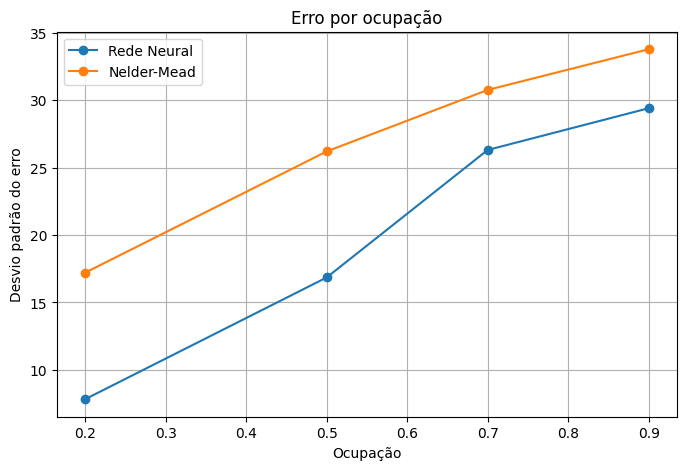

In [43]:

# Gráfico do desvio padrão por ocupação - RN


plt.figure(figsize=(8,5))

plt.plot(
    stats_df['Occupancy'],
    stats_df['Test_STD'],
    marker='o',
    label='Rede Neural'
)


# Gráfico do desvio padrão por ocupação - NM

nm_df = pd.read_csv("nm_stats.csv")
nm_df['occupancy'] = (nm_df['occupancy'].str.replace('occ', '', regex=False).astype(float))
plt.plot(
    nm_df['occupancy'],
    nm_df['std'],
    marker='o',
    label='Nelder-Mead'
)

plt.xlabel('Ocupação')
plt.ylabel('Desvio padrão do erro')

plt.title('Erro por ocupação')

plt.grid(True)
plt.legend()
plt.show()



